In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, re
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import time
import PINN
from PINN import reader, models, pl, tl
from PINN.models._density_transport import Density_Transfer, DT_analysis
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchdiffeq import odeint

import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import Patch

import palantir
# import cellrank as cr
import scvelo as scv


os.chdir("/home/wz369/rds/hpc-work/PINN_dynamics")

In [2]:
from importlib import reload
from PINN.models import _density_transport as PDT
reload(PDT)

<module 'PINN.models._density_transport' from '/rds/user/wz369/hpc-work/PINN_dynamics/PINN/models/_density_transport.py'>

In [3]:
sc.settings.set_figure_params(frameon=False, dpi=50, figsize=(3,3))

In [4]:
adata = sc.read_h5ad('data/ery_mk_Aug1.h5ad')

# load trajectory

# evaluate by distance

In [5]:
from torchcfm.optimal_transport import wasserstein

In [6]:
adata

AnnData object with n_obs × n_vars = 22740 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

# load configs, dataset and models

In [7]:
config_dir = "logs/ery_mk_Aug1_multiscaled_n7_minminus/pde_params_tsense"
result_dir = "results/ery_mk_Aug1_multiscaled_n7_minminus"

In [9]:
configs = [file for file in os.listdir(config_dir) if file.endswith(".json")]


In [8]:
# load config for different runs
config_dict = {}
model_dict = {}

for js in os.listdir(config_dir):     
    if not js.endswith(".json"):
        continue

    v = js.split("_")[0][1:] # after V
    config = PINN.ExperimentConfig(os.path.join(config_dir, js))
    config.experiment_config['checkpoint_dir'] = config.experiment_config['checkpoint_dir'].replace("/ssd/users/Wergillius/Project/PINN_dynamics", "/home/wz369/rds/hpc-work/PINN_dynamics")
    config_dict[v] = config

    print(v)
    ckpt = config.find_lastest_ckpt()
    print(ckpt)     # print checkpoint 

    model_dict[v] = PINN.models.pde_params.load_from_checkpoint(ckpt, map_location='cpu')
    print("/n")

0
/rds/user/wz369/hpc-work/PINN_dynamics/logs/ery_mk_Aug1_multiscaled_n7_minminus/pde_params_tsense/lightning_logs/version_0/checkpoints/epoch=208-val_loss=1.36185145.ckpt
/n
1
/rds/user/wz369/hpc-work/PINN_dynamics/logs/ery_mk_Aug1_multiscaled_n7_minminus/pde_params_tsense/lightning_logs/version_1/checkpoints/epoch=150-val_loss=0.91105741.ckpt
/n
4
/rds/user/wz369/hpc-work/PINN_dynamics/logs/ery_mk_Aug1_multiscaled_n7_minminus/pde_params_tsense/lightning_logs/version_4/checkpoints/epoch=110-val_loss=2.43262768.ckpt
/n
6
/rds/user/wz369/hpc-work/PINN_dynamics/logs/ery_mk_Aug1_multiscaled_n7_minminus/pde_params_tsense/lightning_logs/version_6/checkpoints/epoch=69-val_loss=1.40800607.ckpt
/n
5
/rds/user/wz369/hpc-work/PINN_dynamics/logs/ery_mk_Aug1_multiscaled_n7_minminus/pde_params_tsense/lightning_logs/version_5/checkpoints/epoch=86-val_loss=1.89227855.ckpt
/n


In [10]:
ds_config = config_dict["0"].dataset_config
ds_config['knn_volume'] = eval(config.raw_args['knn_volume'])

DS_full = reader.TwoTimpepoint_AnnDS(adata, split=None, **ds_config)


Dataset : Computing density :
	 `density_funs` not specified, default estimator gaussian kde
Dataset : all cells are used


# test stochastic trajectory

In [11]:
reload(PDT)

<module 'PINN.models._density_transport' from '/rds/user/wz369/hpc-work/PINN_dynamics/PINN/models/_density_transport.py'>

In [14]:
# test model : version 2
device = "cpu" #'cuda:0'
pde_model = model_dict['5'].to(device)
DT_v2 = PDT.Density_Transfer(pde_model, stochastic=True)

In [15]:
adata.obs['anno_man'].cat.categories

Index(['Ery', 'HSC', 'Int prog', 'Meg'], dtype='object')

In [21]:
stemproj = ['HSC'] #, 'Int prog'
timepoint_key = 'timepoint_tx_days'
celltype_key = 'anno_man'
timepoint_tx_days = sorted(adata.obs[timepoint_key].unique())
t0 = timepoint_tx_days[0]

ad_n6 = DS_full.adata

transport_time = None
n_interval = 10
n_repeat = 10

HSC_cbs = []
traj_dict = {}

for it,t in tqdm(enumerate(timepoint_tx_days[:6])):

    if transport_time is not None:
        t2 = t+transport_time
    else:
        t2 = timepoint_tx_days[it+1]
    
    if ds_config['norm_time']=='min_minus':
        t1 = t - t0         # starting timepoint for simulation
        t2 = t2 - t0        # ending timepoint for simulation
    else:
        t1 = t/t0
        t2 /= t0
        
    integrate_time = np.linspace(t1, t2 ,n_interval+1) / pde_model.time_scale_factor
        
    
    # find cell of time
    start_cell = ad_n6.obs.query(f"`{celltype_key}` in @stemproj & `{timepoint_key}` == @t").index
    start_cell = list(start_cell)
    HSC_cbs.append(start_cell)

    # define initital density and cellstates
    cell_index = [np.where(ad_n6.obs_names == x)[0].item() for x in start_cell]
    u0 = DS_full.u_b[it, cell_index].float().to(device)
    s0 = torch.from_numpy(DS_full.cellstate[cell_index]).float().to(device)

    
    print(integrate_time)
    S_trajectory = [DT_v2.cellstate_drift(s0, integrate_time) for i in range(n_repeat)]
    traj_dict[str(t)] =  np.stack(S_trajectory)

0it [00:00, ?it/s]

[0.  0.4 0.8 1.2 1.6 2.  2.4 2.8 3.2 3.6 4. ]
[4.  4.5 5.  5.5 6.  6.5 7.  7.5 8.  8.5 9. ]
[ 9.  10.5 12.  13.5 15.  16.5 18.  19.5 21.  22.5 24. ]
[24.  26.2 28.4 30.6 32.8 35.  37.2 39.4 41.6 43.8 46. ]
[46.  48.7 51.4 54.1 56.8 59.5 62.2 64.9 67.6 70.3 73. ]
[ 73.   76.6  80.2  83.8  87.4  91.   94.6  98.2 101.8 105.4 109. ]


In [22]:
np.stack(S_trajectory).shape

(10, 11, 498, 3)

### find the cloest cells

In [53]:
from tqdm import tqdm


sim_nn_dict = {}
for day, Trajs in traj_dict.items():

    nn = []
    for r in tqdm(range(3)): # repeat  

        nn_steps = []
        for step in range(1,11):  # step
            nns = tl.assign_nearest_cell(Trajs[r,step], ad_n6, cellstate_key=ds_config['cellstate_key'], n_neighbors=5)
            nn_steps.append(nns)
        nn.append(nn_steps)

    sim_nn_dict[day] = nn 

100%|██████████| 3/3 [00:01<00:00,  2.10it/s]


In [23]:
# by cell type
def summarize_cell_proportions(df, celltype_list):
    """
    Summarizes the proportion of cell types mapped from neighbors for each cell

    Inputs:
    df : Input DataFrame where each column represents a cell and each row a sample.
    celltype_list : List of cell types to include in the output as columns.
    """
    # Compute normalized value counts for each cell
    proportions = df.apply(lambda col: col.value_counts(normalize=True))
    proportions = proportions.fillna(0).T # cell as index

    # Reindex columns to match the given celltype_list, filling missing with 0
    proportions = proportions.reindex(columns=celltype_list, fill_value=0)

    return proportions

In [27]:
celltype_list = ad_n6.obs['anno_man'].cat.categories

traj_ct_dict = {}

for day, Trajs in traj_dict.items():
    ct_df_steps = []
    for step in tqdm(range(1,11)):  # step

        # prop_step = pd.DataFrame()
        ncell = Trajs[0,step].shape[0]
        prop_step = np.zeros((ncell,len(celltype_list)))
        
        for r in range(n_repeat):
            cts = tl.assign_nearest_cell(Trajs[r,step], ad_n6, cellstate_key=ds_config['cellstate_key'], n_neighbors=5, annotation='anno_man')
            props = summarize_cell_proportions(cts, celltype_list)
            prop_step += props.values
        
        prop_step = pd.DataFrame(prop_step, columns=celltype_list) /n_repeat 
        prop_step['step'] = step
        ct_df_steps.append(prop_step)

    traj_ct_dict[day] = pd.concat(ct_df_steps)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [37]:
traj_ct_dict['12'].query("`Ery` > 0")

,Ery,HSC,Int prog,Meg,step


In [39]:
traj_ct_dict['3'].query("`Ery` > 0")

,Ery,HSC,Int prog,Meg,step


In [35]:
traj_ct_dict['27'].query("`Ery` > 0")

,Ery,HSC,Int prog,Meg,step
2,0.20,0.0,0.80,0.00,2
311,0.04,0.0,0.96,0.00,2
0,0.16,0.0,0.84,0.00,3
2,1.00,0.0,0.00,0.00,3
5,0.16,0.0,0.84,0.00,3
...,...,...,...,...,...
240,0.32,0.3,0.08,0.30,5
267,0.16,0.1,0.06,0.68,5
304,0.08,0.2,0.04,0.68,5
341,0.16,0.3,0.06,0.48,5


In [33]:
traj_ct_dict['49']

,Ery,HSC,Int prog,Meg,step
0,0.0,0.0,1.00,0.00,1
1,0.0,0.0,1.00,0.00,1
2,0.0,0.0,0.98,0.02,1
3,0.0,0.0,1.00,0.00,1
4,0.0,0.0,1.00,0.00,1
...,...,...,...,...,...
276,0.8,0.0,0.00,0.20,10
277,0.3,0.0,0.00,0.70,10
278,0.3,0.0,0.00,0.70,10
279,0.0,0.0,0.00,1.00,10


In [68]:
pd.concat([pd.DataFrame(df.mean(axis=0)).T for df in traj_ct_dict['76']])

,Ery,HSC,Int prog,Meg
0,0.003680,0.450721,0.509230,0.036369
0,0.001595,0.440662,0.515057,0.042686
0,0.001288,0.430359,0.517755,0.050598
0,0.001165,0.422938,0.519902,0.055995
0,0.000920,0.414597,0.520025,0.064459
0,0.000797,0.407053,0.513953,0.078197
0,0.000675,0.399693,0.506838,0.092794
0,0.000859,0.392027,0.497700,0.109414
0,0.000859,0.381785,0.491138,0.126219
0,0.000981,0.373014,0.478074,0.147930


In [20]:
# TODO: calculate pseudotime
# TODO: calculate distance

In [11]:
from PINN.models import DT_analysis

In [12]:
DT_dict = {}
for v in config_dict.keys():
    DT_dict[v] = DT_analysis(adata, f'results/ery_mk_Aug1_multiscaled_n7_minminus/pde_params_tsense_{v}')

cell type proportion summary detected
adding to  ct_prop property
cell type proportion summary detected
adding to  ct_prop property
cell type proportion summary detected
adding to  ct_prop property
cell type proportion summary detected
adding to  ct_prop property
cell type proportion summary detected
adding to  ct_prop property


In [37]:
np.log(DT_dict['5'].TM_norm_dict['27'][:,9,:])

array([[        -inf,         -inf,         -inf, ...,         -inf,
                -inf,         -inf],
       [        -inf,         -inf,         -inf, ...,         -inf,
                -inf,         -inf],
       [ -2.64508426,  -6.7875565 , -11.82801863, ...,         -inf,
                -inf,         -inf],
       ...,
       [        -inf,         -inf,         -inf, ...,         -inf,
                -inf,         -inf],
       [        -inf,         -inf,         -inf, ...,         -inf,
                -inf,         -inf],
       [        -inf,         -inf,         -inf, ...,         -inf,
                -inf,         -inf]])

In [55]:
DT_dict['5'].TM_norm_dict['161']

array([[[3.88400607e-03, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [7.74223156e-03, 2.02362644e-05, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.15746990e-02, 6.04868073e-05, 1.35748285e-07, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [3.03516191e-02, 5.54258256e-04, 7.44368352e-06, ...,
         7.48355162e-18, 0.00000000e+00, 0.00000000e+00],
        [3.40301156e-02, 7.09991886e-04, 1.11185755e-05, ...,
         6.69323998e-17, 5.39802409e-20, 0.00000000e+00],
        [3.76830916e-02, 8.84217114e-04, 1.58168420e-05, ...,
         3.32577182e-16, 5.36451187e-19, 3.25821306e-22]],

       [[2.51545626e-03, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [5.01419204e-03, 8.76938924e-06, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [7.49619354e-03, 

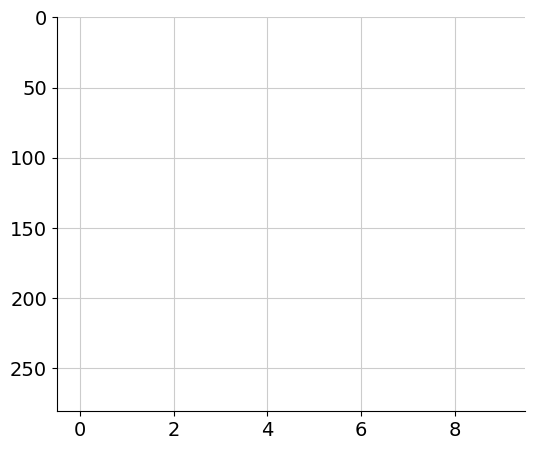

In [62]:
fig = plt.figure(figsize=(6,6))
ax = fig.gca()
ax.imshow(np.log(DT_dict['5'].TM_norm_dict['49'][:,9,:]), aspect=0.03);

In [26]:
DT_dict['5'].ct_prop.query('step==10 & Day == 27')[["Ery","HSC","Int prog","Meg"]]

,Ery,HSC,Int prog,Meg
9,0.566667,0.0,0.133333,0.300000
19,0.500000,0.0,0.433333,0.066667
29,0.966667,0.0,0.033333,0.000000
39,0.466667,0.0,0.133333,0.400000
49,0.466667,0.0,0.133333,0.400000
...,...,...,...,...
3819,0.666667,0.0,0.200000,0.133333
3829,1.000000,0.0,0.000000,0.000000
3839,0.566667,0.0,0.133333,0.300000
3849,0.466667,0.0,0.433333,0.100000
